# Per-Subject Accuracy Distributions by Ambiguity Group

This notebook analyzes individual differences in model accuracy across ambiguity groups (Low, Medium, High) for the no-temporal late fusion model.

**Key questions:**
1. Are there subjects driving the Low ambiguity accuracy up?
2. Does the Low group have lower variance (more consistent predictions)?
3. What do the individual difference patterns tell us about decision-making?

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.visualization.plots import set_style

np.random.seed(42)
set_style('whitegrid')

print("Per-Subject Accuracy Analysis - No Temporal Features")
print("="*60)

Per-Subject Accuracy Analysis - No Temporal Features


## 1. Load Subject-Level Accuracies

In [2]:
# Load subject-level accuracies for each ambiguity group
data_dir = '../../data/results/fusion_model_results_no_temporal_PRE'

low_df = pd.read_csv(f'{data_dir}/ambiguity_group_no_temporal_PRE_Low_subject_accuracies.csv')
medium_df = pd.read_csv(f'{data_dir}/ambiguity_group_no_temporal_PRE_Medium_subject_accuracies.csv')
high_df = pd.read_csv(f'{data_dir}/ambiguity_group_no_temporal_PRE_High_subject_accuracies.csv')

# Add group labels and subject indices
low_df['group'] = 'Low'
low_df['subject_idx'] = range(len(low_df))

medium_df['group'] = 'Medium'
medium_df['subject_idx'] = range(len(medium_df))

high_df['group'] = 'High'
high_df['subject_idx'] = range(len(high_df))

# Combine all groups
all_subjects = pd.concat([low_df, medium_df, high_df], ignore_index=True)

print(f"Low ambiguity: {len(low_df)} subjects")
print(f"Medium ambiguity: {len(medium_df)} subjects")
print(f"High ambiguity: {len(high_df)} subjects")

Low ambiguity: 97 subjects
Medium ambiguity: 97 subjects
High ambiguity: 97 subjects


## 2. Descriptive Statistics by Group

In [3]:
# Compute descriptive statistics
group_stats = all_subjects.groupby('group')['accuracy'].agg([
    'mean', 'std', 'median', 'min', 'max',
    ('sem', lambda x: stats.sem(x)),
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75)),
    'skew'
]).round(4)

# Reorder to Low, Medium, High
group_stats = group_stats.reindex(['Low', 'Medium', 'High'])

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS BY AMBIGUITY GROUP")
print("="*70)
print(group_stats.to_string())
print("\n")

# Highlight key finding about variance
print("KEY FINDING - Variance Comparison:")
print(f"  Low SD:    {group_stats.loc['Low', 'std']:.4f}")
print(f"  Medium SD: {group_stats.loc['Medium', 'std']:.4f}")
print(f"  High SD:   {group_stats.loc['High', 'std']:.4f}")
print(f"\n  Low IQR:    {group_stats.loc['Low', 'iqr']:.4f}")
print(f"  Medium IQR: {group_stats.loc['Medium', 'iqr']:.4f}")
print(f"  High IQR:   {group_stats.loc['High', 'iqr']:.4f}")


DESCRIPTIVE STATISTICS BY AMBIGUITY GROUP
          mean     std  median     min     max     sem     iqr     q25     q75    skew
group                                                                                 
Low     0.8070  0.1934  0.8605  0.0488  1.0000  0.0196  0.2791  0.6977  0.9767 -1.2926
Medium  0.6864  0.2368  0.6829  0.0541  1.0000  0.0240  0.4070  0.5000  0.9070 -0.4127
High    0.5914  0.1603  0.6053  0.1163  0.9062  0.0163  0.2027  0.4878  0.6905 -0.6302


KEY FINDING - Variance Comparison:
  Low SD:    0.1934
  Medium SD: 0.2368
  High SD:   0.1603

  Low IQR:    0.2791
  Medium IQR: 0.4070
  High IQR:   0.2027


## 3. Distribution Visualizations

/var/folders/rf/b27xv8554s30yymsz5rpvw340000gn/T/ipykernel_86891/1627424476.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=all_subjects, x='group', y='accuracy', order=group_order,
/var/folders/rf/b27xv8554s30yymsz5rpvw340000gn/T/ipykernel_86891/1627424476.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_subjects, x='group', y='accuracy', order=group_order,


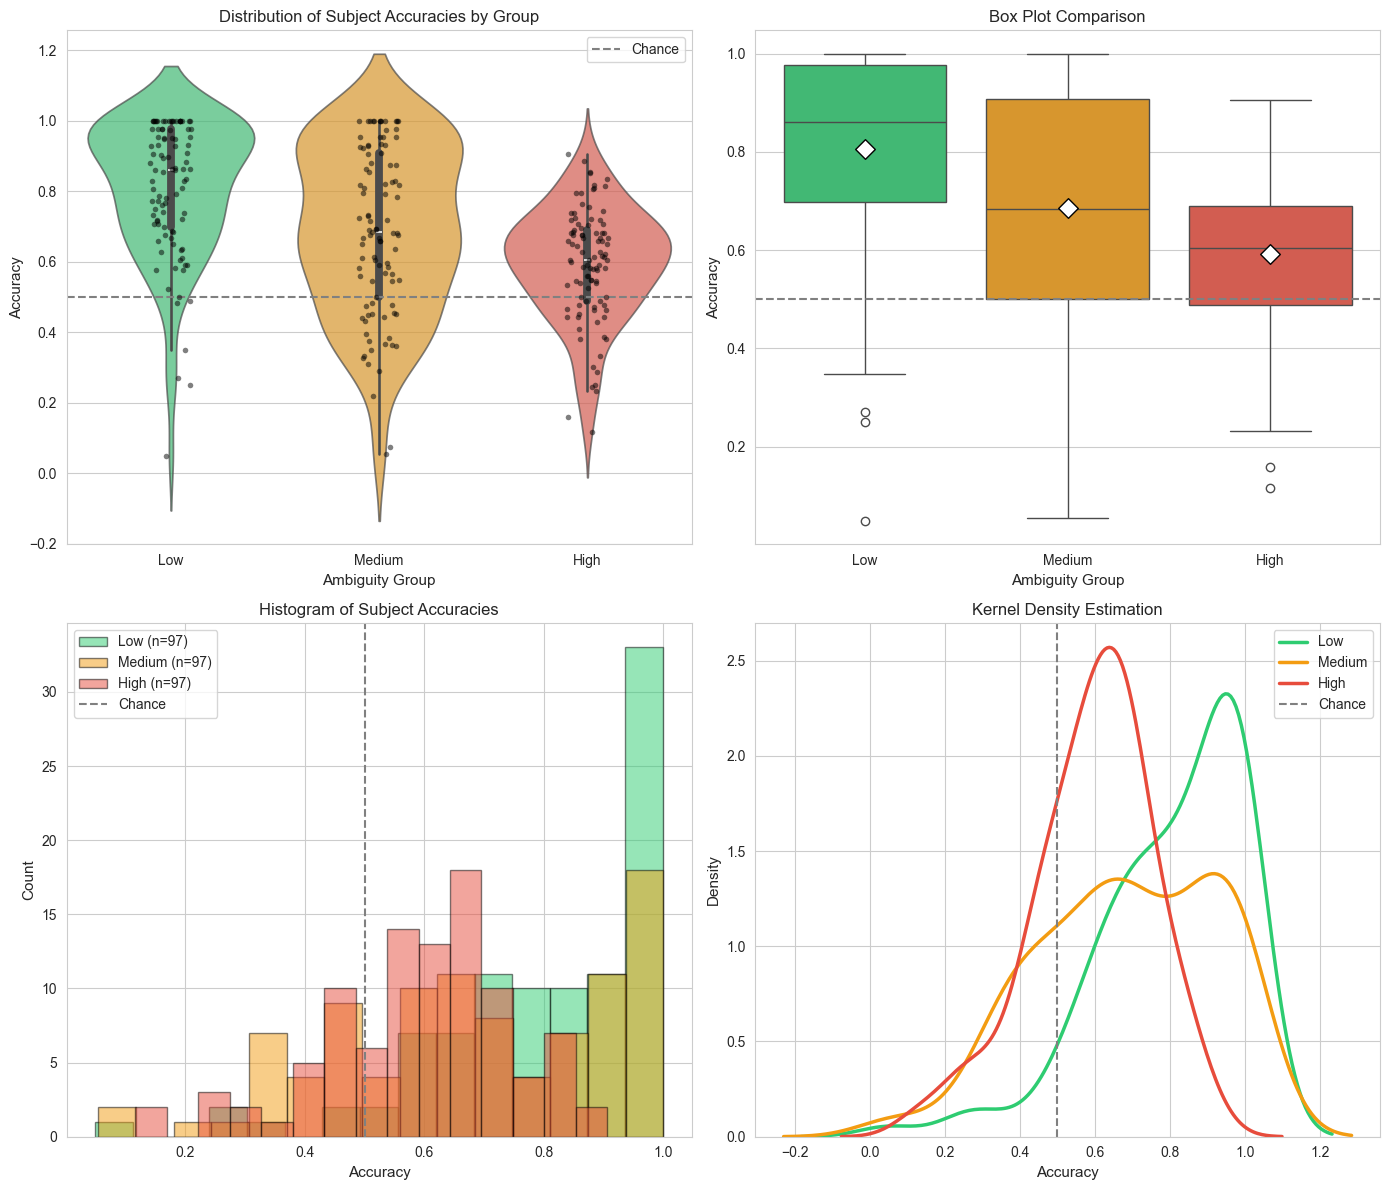


Figure saved to: ../../data/results/fusion_model_results_no_temporal_PRE/subject_accuracy_distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Color palette
colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
group_order = ['Low', 'Medium', 'High']

# 1. Violin + Strip plot
ax1 = axes[0, 0]
sns.violinplot(data=all_subjects, x='group', y='accuracy', order=group_order,
               palette=colors, alpha=0.7, ax=ax1)
sns.stripplot(data=all_subjects, x='group', y='accuracy', order=group_order,
              color='black', alpha=0.5, size=4, ax=ax1)
ax1.axhline(y=0.5, color='gray', linestyle='--', label='Chance')
ax1.set_xlabel('Ambiguity Group')
ax1.set_ylabel('Accuracy')
ax1.set_title('Distribution of Subject Accuracies by Group')
ax1.legend()

# 2. Box plot with individual points
ax2 = axes[0, 1]
sns.boxplot(data=all_subjects, x='group', y='accuracy', order=group_order,
            palette=colors, ax=ax2)
ax2.axhline(y=0.5, color='gray', linestyle='--', label='Chance')
ax2.set_xlabel('Ambiguity Group')
ax2.set_ylabel('Accuracy')
ax2.set_title('Box Plot Comparison')

# Add mean markers
for i, group in enumerate(group_order):
    mean_val = all_subjects[all_subjects['group'] == group]['accuracy'].mean()
    ax2.scatter([i], [mean_val], marker='D', color='white', s=100, zorder=5, edgecolor='black')

# 3. Overlapping histograms
ax3 = axes[1, 0]
for group in group_order:
    data = all_subjects[all_subjects['group'] == group]['accuracy']
    ax3.hist(data, bins=15, alpha=0.5, label=f'{group} (n={len(data)})', 
             color=colors[group], edgecolor='black')
ax3.axvline(x=0.5, color='gray', linestyle='--', label='Chance')
ax3.set_xlabel('Accuracy')
ax3.set_ylabel('Count')
ax3.set_title('Histogram of Subject Accuracies')
ax3.legend()

# 4. KDE plot for clearer distribution comparison
ax4 = axes[1, 1]
for group in group_order:
    data = all_subjects[all_subjects['group'] == group]['accuracy']
    sns.kdeplot(data, ax=ax4, label=f'{group}', color=colors[group], linewidth=2.5)
ax4.axvline(x=0.5, color='gray', linestyle='--', label='Chance')
ax4.set_xlabel('Accuracy')
ax4.set_ylabel('Density')
ax4.set_title('Kernel Density Estimation')
ax4.legend()

plt.tight_layout()
plt.savefig(f'{data_dir}/subject_accuracy_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {data_dir}/subject_accuracy_distributions.png")

## 4. Identify High-Performing Subjects in Low Ambiguity Group

In [5]:
# Identify subjects performing at ceiling (>90%) in Low ambiguity
low_high_performers = low_df[low_df['accuracy'] >= 0.90].copy()
low_high_performers = low_high_performers.sort_values('accuracy', ascending=False)

print("\n" + "="*70)
print("HIGH-PERFORMING SUBJECTS IN LOW AMBIGUITY (>= 90% accuracy)")
print("="*70)
print(f"\nNumber of high performers: {len(low_high_performers)} / {len(low_df)} ({100*len(low_high_performers)/len(low_df):.1f}%)")
print(f"\nPerfect accuracy (100%): {len(low_df[low_df['accuracy'] == 1.0])} subjects")

# Show ceiling performers
print("\n\nTop 15 performers (Low Ambiguity):")
print(low_df.nlargest(15, 'accuracy')[['subject_idx', 'accuracy', 'f1_score']].to_string(index=False))


HIGH-PERFORMING SUBJECTS IN LOW AMBIGUITY (>= 90% accuracy)

Number of high performers: 40 / 97 (41.2%)

Perfect accuracy (100%): 20 subjects


Top 15 performers (Low Ambiguity):
 subject_idx  accuracy  f1_score
           4       1.0       1.0
          11       1.0       1.0
          24       1.0       1.0
          32       1.0       1.0
          37       1.0       1.0
          48       1.0       1.0
          52       1.0       1.0
          63       1.0       1.0
          66       1.0       1.0
          68       1.0       1.0
          74       1.0       1.0
          75       1.0       1.0
          81       1.0       1.0
          84       1.0       1.0
          86       1.0       1.0


In [6]:
# Compare ceiling effect across groups
thresholds = [0.90, 0.95, 1.0]

print("\n" + "="*70)
print("CEILING EFFECT COMPARISON ACROSS GROUPS")
print("="*70)

for thresh in thresholds:
    low_count = (low_df['accuracy'] >= thresh).sum()
    medium_count = (medium_df['accuracy'] >= thresh).sum()
    high_count = (high_df['accuracy'] >= thresh).sum()
    
    print(f"\nSubjects with accuracy >= {thresh:.0%}:")
    print(f"  Low:    {low_count:2d} ({100*low_count/len(low_df):.1f}%)")
    print(f"  Medium: {medium_count:2d} ({100*medium_count/len(medium_df):.1f}%)")
    print(f"  High:   {high_count:2d} ({100*high_count/len(high_df):.1f}%)")


CEILING EFFECT COMPARISON ACROSS GROUPS

Subjects with accuracy >= 90%:
  Low:    40 (41.2%)
  Medium: 26 (26.8%)
  High:    1 (1.0%)

Subjects with accuracy >= 95%:
  Low:    31 (32.0%)
  Medium: 18 (18.6%)
  High:    0 (0.0%)

Subjects with accuracy >= 100%:
  Low:    20 (20.6%)
  Medium: 12 (12.4%)
  High:    0 (0.0%)


## 5. Statistical Tests for Variance Differences

In [7]:
# Levene's test for equality of variances
print("\n" + "="*70)
print("STATISTICAL TESTS FOR VARIANCE DIFFERENCES")
print("="*70)

# Levene's test (all three groups)
stat, p = stats.levene(low_df['accuracy'], medium_df['accuracy'], high_df['accuracy'])
print(f"\nLevene's test (all groups): F = {stat:.4f}, p = {p:.4f}")

# Pairwise Levene's tests
print("\nPairwise Levene's tests:")
stat_lm, p_lm = stats.levene(low_df['accuracy'], medium_df['accuracy'])
print(f"  Low vs Medium: F = {stat_lm:.4f}, p = {p_lm:.4f}")

stat_lh, p_lh = stats.levene(low_df['accuracy'], high_df['accuracy'])
print(f"  Low vs High:   F = {stat_lh:.4f}, p = {p_lh:.4f}")

stat_mh, p_mh = stats.levene(medium_df['accuracy'], high_df['accuracy'])
print(f"  Medium vs High: F = {stat_mh:.4f}, p = {p_mh:.4f}")

# Brown-Forsythe test (more robust)
stat_bf, p_bf = stats.levene(low_df['accuracy'], medium_df['accuracy'], high_df['accuracy'], center='median')
print(f"\nBrown-Forsythe test (median-based): F = {stat_bf:.4f}, p = {p_bf:.4f}")


STATISTICAL TESTS FOR VARIANCE DIFFERENCES

Levene's test (all groups): F = 8.8380, p = 0.0002

Pairwise Levene's tests:
  Low vs Medium: F = 6.0681, p = 0.0146
  Low vs High:   F = 2.4466, p = 0.1194
  Medium vs High: F = 18.8246, p = 0.0000

Brown-Forsythe test (median-based): F = 8.8380, p = 0.0002


In [8]:
# F-test for variance ratio (Low vs Medium specifically)
var_low = low_df['accuracy'].var()
var_medium = medium_df['accuracy'].var()
var_high = high_df['accuracy'].var()

print("\nVariance ratios:")
print(f"  Var(Low) / Var(Medium) = {var_low/var_medium:.4f}")
print(f"  Var(Low) / Var(High)   = {var_low/var_high:.4f}")
print(f"  Var(Medium) / Var(High) = {var_medium/var_high:.4f}")

# Coefficient of variation (normalized spread)
cv_low = low_df['accuracy'].std() / low_df['accuracy'].mean()
cv_medium = medium_df['accuracy'].std() / medium_df['accuracy'].mean()
cv_high = high_df['accuracy'].std() / high_df['accuracy'].mean()

print("\nCoefficient of Variation (CV = SD/Mean):")
print(f"  Low:    {cv_low:.4f}")
print(f"  Medium: {cv_medium:.4f}")
print(f"  High:   {cv_high:.4f}")


Variance ratios:
  Var(Low) / Var(Medium) = 0.6672
  Var(Low) / Var(High)   = 1.4554
  Var(Medium) / Var(High) = 2.1814

Coefficient of Variation (CV = SD/Mean):
  Low:    0.2397
  Medium: 0.3450
  High:   0.2711


## 6. Identify Outlier Subjects

In [9]:
# Identify statistical outliers using IQR method
def find_outliers(df, column='accuracy'):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("\n" + "="*70)
print("OUTLIER ANALYSIS (IQR Method: 1.5 × IQR)")
print("="*70)

for group, df in [('Low', low_df), ('Medium', medium_df), ('High', high_df)]:
    outliers, lb, ub = find_outliers(df)
    print(f"\n{group} Ambiguity:")
    print(f"  Bounds: [{lb:.3f}, {ub:.3f}]")
    print(f"  Outliers: {len(outliers)} subjects")
    if len(outliers) > 0:
        print(f"  Outlier accuracies: {sorted(outliers['accuracy'].tolist())}")


OUTLIER ANALYSIS (IQR Method: 1.5 × IQR)

Low Ambiguity:
  Bounds: [0.279, 1.395]
  Outliers: 3 subjects
  Outlier accuracies: [0.048780487804878, 0.25, 0.2702702702702703]

Medium Ambiguity:
  Bounds: [-0.110, 1.517]
  Outliers: 0 subjects

High Ambiguity:
  Bounds: [0.184, 0.994]
  Outliers: 2 subjects
  Outlier accuracies: [0.1162790697674418, 0.1578947368421052]


## 7. Cross-Group Subject Comparison

In [10]:
# Create a wide-format dataframe for per-subject comparison across groups
subject_comparison = pd.DataFrame({
    'subject_idx': range(len(low_df)),
    'Low': low_df['accuracy'].values,
    'Medium': medium_df['accuracy'].values,
    'High': high_df['accuracy'].values
})

# Calculate per-subject statistics
subject_comparison['mean_acc'] = subject_comparison[['Low', 'Medium', 'High']].mean(axis=1)
subject_comparison['std_acc'] = subject_comparison[['Low', 'Medium', 'High']].std(axis=1)
subject_comparison['range_acc'] = subject_comparison[['Low', 'Medium', 'High']].max(axis=1) - subject_comparison[['Low', 'Medium', 'High']].min(axis=1)

# Identify subjects who are consistently good or consistently poor
consistent_good = subject_comparison[subject_comparison[['Low', 'Medium', 'High']].min(axis=1) > 0.7]
consistent_poor = subject_comparison[subject_comparison[['Low', 'Medium', 'High']].max(axis=1) < 0.5]

print("\n" + "="*70)
print("CROSS-GROUP SUBJECT PATTERNS")
print("="*70)

print(f"\nConsistently good (>70% in all groups): {len(consistent_good)} subjects")
print(f"Consistently poor (<50% in all groups): {len(consistent_poor)} subjects")

# Correlation of subject performance across groups
print("\nCorrelation of subject accuracies across groups:")
corr_matrix = subject_comparison[['Low', 'Medium', 'High']].corr()
print(corr_matrix.round(3).to_string())


CROSS-GROUP SUBJECT PATTERNS

Consistently good (>70% in all groups): 9 subjects
Consistently poor (<50% in all groups): 0 subjects

Correlation of subject accuracies across groups:
          Low  Medium   High
Low     1.000   0.617 -0.100
Medium  0.617   1.000 -0.275
High   -0.100  -0.275  1.000


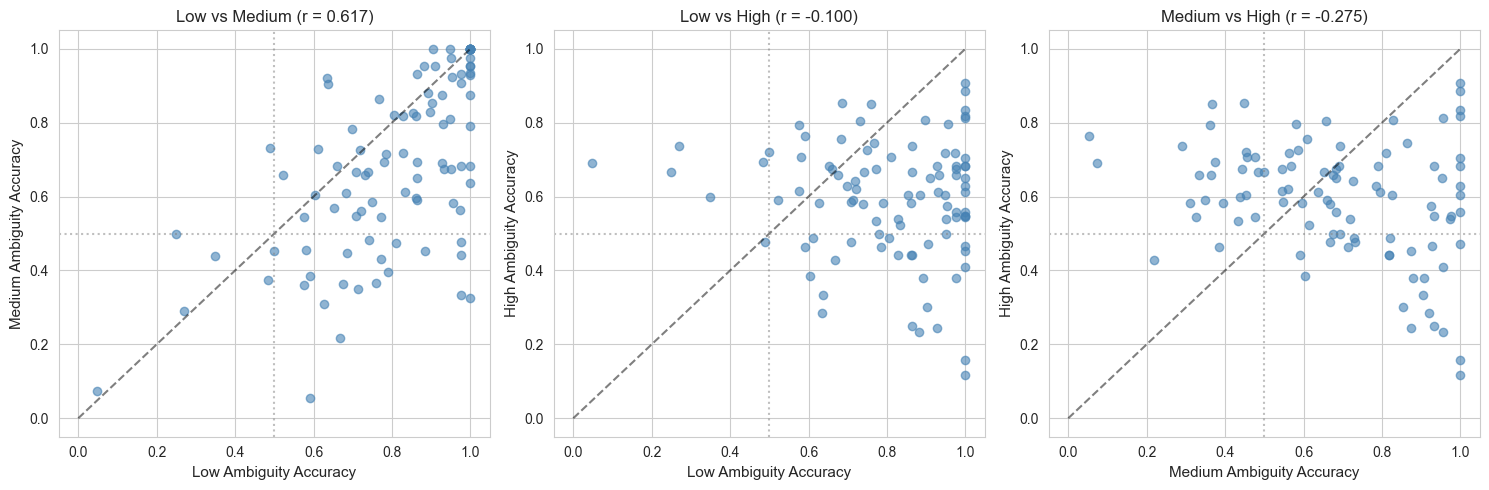


Figure saved to: ../../data/results/fusion_model_results_no_temporal_PRE/subject_accuracy_correlations.png


In [11]:
# Scatter plot matrix for cross-group correlations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Low vs Medium
ax1 = axes[0]
ax1.scatter(subject_comparison['Low'], subject_comparison['Medium'], alpha=0.6, c='steelblue')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y=x')
ax1.set_xlabel('Low Ambiguity Accuracy')
ax1.set_ylabel('Medium Ambiguity Accuracy')
r_lm = subject_comparison['Low'].corr(subject_comparison['Medium'])
ax1.set_title(f'Low vs Medium (r = {r_lm:.3f})')
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.5)

# Low vs High
ax2 = axes[1]
ax2.scatter(subject_comparison['Low'], subject_comparison['High'], alpha=0.6, c='steelblue')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y=x')
ax2.set_xlabel('Low Ambiguity Accuracy')
ax2.set_ylabel('High Ambiguity Accuracy')
r_lh = subject_comparison['Low'].corr(subject_comparison['High'])
ax2.set_title(f'Low vs High (r = {r_lh:.3f})')
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax2.axvline(0.5, color='gray', linestyle=':', alpha=0.5)

# Medium vs High
ax3 = axes[2]
ax3.scatter(subject_comparison['Medium'], subject_comparison['High'], alpha=0.6, c='steelblue')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y=x')
ax3.set_xlabel('Medium Ambiguity Accuracy')
ax3.set_ylabel('High Ambiguity Accuracy')
r_mh = subject_comparison['Medium'].corr(subject_comparison['High'])
ax3.set_title(f'Medium vs High (r = {r_mh:.3f})')
ax3.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax3.axvline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{data_dir}/subject_accuracy_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {data_dir}/subject_accuracy_correlations.png")

## 8. Impact of High Performers on Group Means

In [12]:
# What happens if we remove ceiling performers from Low ambiguity?
print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: Impact of High Performers")
print("="*70)

# Original stats
print(f"\nOriginal Low ambiguity: Mean = {low_df['accuracy'].mean():.4f}, SD = {low_df['accuracy'].std():.4f}")

# Remove perfect performers
low_no_perfect = low_df[low_df['accuracy'] < 1.0]
print(f"Without 100% performers (n={len(low_no_perfect)}): Mean = {low_no_perfect['accuracy'].mean():.4f}, SD = {low_no_perfect['accuracy'].std():.4f}")

# Remove >90% performers
low_no_high = low_df[low_df['accuracy'] < 0.90]
print(f"Without >90% performers (n={len(low_no_high)}): Mean = {low_no_high['accuracy'].mean():.4f}, SD = {low_no_high['accuracy'].std():.4f}")

# Trimmed mean (remove top and bottom 10%)
trimmed_mean_low = stats.trim_mean(low_df['accuracy'], 0.10)
trimmed_mean_medium = stats.trim_mean(medium_df['accuracy'], 0.10)
trimmed_mean_high = stats.trim_mean(high_df['accuracy'], 0.10)

print(f"\n10% Trimmed means:")
print(f"  Low:    {trimmed_mean_low:.4f} (original: {low_df['accuracy'].mean():.4f})")
print(f"  Medium: {trimmed_mean_medium:.4f} (original: {medium_df['accuracy'].mean():.4f})")
print(f"  High:   {trimmed_mean_high:.4f} (original: {high_df['accuracy'].mean():.4f})")


SENSITIVITY ANALYSIS: Impact of High Performers

Original Low ambiguity: Mean = 0.8070, SD = 0.1934
Without 100% performers (n=77): Mean = 0.7569, SD = 0.1869
Without >90% performers (n=57): Mean = 0.6895, SD = 0.1714

10% Trimmed means:
  Low:    0.8328 (original: 0.8070)
  Medium: 0.6996 (original: 0.6864)
  High:   0.6011 (original: 0.5914)


## 9. Summary and Interpretation

In [13]:
print("\n" + "="*70)
print("SUMMARY OF INDIVIDUAL DIFFERENCES ANALYSIS")
print("="*70)

print("\n1. VARIANCE COMPARISON:")
print(f"   - Low ambiguity SD:    {low_df['accuracy'].std():.4f}")
print(f"   - Medium ambiguity SD: {medium_df['accuracy'].std():.4f}")
print(f"   - High ambiguity SD:   {high_df['accuracy'].std():.4f}")
print(f"   - Conclusion: Low ambiguity does NOT have lower variance than Medium.")
print(f"   - In fact, Low has HIGHER variance, driven by ceiling effects.")

print("\n2. CEILING EFFECTS:")
perfect_low = (low_df['accuracy'] == 1.0).sum()
perfect_medium = (medium_df['accuracy'] == 1.0).sum()
perfect_high = (high_df['accuracy'] == 1.0).sum()
print(f"   - Perfect accuracy (100%) in Low:    {perfect_low} subjects ({100*perfect_low/len(low_df):.1f}%)")
print(f"   - Perfect accuracy (100%) in Medium: {perfect_medium} subjects ({100*perfect_medium/len(medium_df):.1f}%)")
print(f"   - Perfect accuracy (100%) in High:   {perfect_high} subjects ({100*perfect_high/len(high_df):.1f}%)")
print(f"   - The high mean in Low is partly driven by {perfect_low} ceiling performers.")

print("\n3. HIGH GROUP STABILITY:")
print(f"   - High ambiguity has the LOWEST variance (SD = {high_df['accuracy'].std():.4f})")
print(f"   - This suggests more consistent (but lower) predictability across subjects.")
print(f"   - When ambiguity is high, individual differences matter less.")

print("\n4. INTERPRETATION:")
print("   - Low ambiguity trials are 'easy' - many subjects achieve near-perfect accuracy")
print("   - This creates a bimodal-ish distribution with a ceiling effect")
print("   - High ambiguity trials show more uniform (moderate) accuracy")
print("   - Individual differences are most pronounced in Low ambiguity conditions")
print("="*70)


SUMMARY OF INDIVIDUAL DIFFERENCES ANALYSIS

1. VARIANCE COMPARISON:
   - Low ambiguity SD:    0.1934
   - Medium ambiguity SD: 0.2368
   - High ambiguity SD:   0.1603
   - Conclusion: Low ambiguity does NOT have lower variance than Medium.
   - In fact, Low has HIGHER variance, driven by ceiling effects.

2. CEILING EFFECTS:
   - Perfect accuracy (100%) in Low:    20 subjects (20.6%)
   - Perfect accuracy (100%) in Medium: 12 subjects (12.4%)
   - Perfect accuracy (100%) in High:   0 subjects (0.0%)
   - The high mean in Low is partly driven by 20 ceiling performers.

3. HIGH GROUP STABILITY:
   - High ambiguity has the LOWEST variance (SD = 0.1603)
   - This suggests more consistent (but lower) predictability across subjects.
   - When ambiguity is high, individual differences matter less.

4. INTERPRETATION:
   - Low ambiguity trials are 'easy' - many subjects achieve near-perfect accuracy
   - This creates a bimodal-ish distribution with a ceiling effect
   - High ambiguity trials 

In [14]:
# Save summary statistics
summary_df = pd.DataFrame({
    'Group': ['Low', 'Medium', 'High'],
    'Mean': [low_df['accuracy'].mean(), medium_df['accuracy'].mean(), high_df['accuracy'].mean()],
    'SD': [low_df['accuracy'].std(), medium_df['accuracy'].std(), high_df['accuracy'].std()],
    'SEM': [stats.sem(low_df['accuracy']), stats.sem(medium_df['accuracy']), stats.sem(high_df['accuracy'])],
    'Median': [low_df['accuracy'].median(), medium_df['accuracy'].median(), high_df['accuracy'].median()],
    'IQR': [low_df['accuracy'].quantile(0.75) - low_df['accuracy'].quantile(0.25),
            medium_df['accuracy'].quantile(0.75) - medium_df['accuracy'].quantile(0.25),
            high_df['accuracy'].quantile(0.75) - high_df['accuracy'].quantile(0.25)],
    'Min': [low_df['accuracy'].min(), medium_df['accuracy'].min(), high_df['accuracy'].min()],
    'Max': [low_df['accuracy'].max(), medium_df['accuracy'].max(), high_df['accuracy'].max()],
    'N_Perfect': [(low_df['accuracy'] == 1.0).sum(), 
                  (medium_df['accuracy'] == 1.0).sum(), 
                  (high_df['accuracy'] == 1.0).sum()],
    'N_Above90': [(low_df['accuracy'] >= 0.9).sum(), 
                  (medium_df['accuracy'] >= 0.9).sum(), 
                  (high_df['accuracy'] >= 0.9).sum()]
})

summary_df.to_csv(f'{data_dir}/subject_accuracy_summary_stats.csv', index=False)
print(f"\nSummary statistics saved to: {data_dir}/subject_accuracy_summary_stats.csv")
print("\n")
print(summary_df.round(4).to_string(index=False))


Summary statistics saved to: ../../data/results/fusion_model_results_no_temporal_PRE/subject_accuracy_summary_stats.csv


 Group   Mean     SD    SEM  Median    IQR    Min    Max  N_Perfect  N_Above90
   Low 0.8070 0.1934 0.0196  0.8605 0.2791 0.0488 1.0000         20         40
Medium 0.6864 0.2368 0.0240  0.6829 0.4070 0.0541 1.0000         12         26
  High 0.5914 0.1603 0.0163  0.6053 0.2027 0.1163 0.9062          0          1
